# 📈 Sistem Rekomendasi Menu Makanan pada Aplikasi Food Delivery Menggunakan Metode Hybrid Recommendation

---

## 👥 Anggota Kelompok
### 1. Hammam Jauharul Karim (1203222050)
### 2. Ferry Oktariansyah (1203220006)
### 3. Jerdin Vanesa (1203220076)
### 4. Jordan Wijayanto (1203220149) 

---

## 📝 Deskripsi Proyek
Proyek ini bertujuan untuk membangun sistem rekomendasi pada aplikasi food delivery yang mampu memberikan rekomendasi menu dan restorannya kepada pengguna. Sistem rekomendasi dikembangkan menggunakan pendekatan **Hybrid Recommendation**, yaitu penggabungan antara **popularity-based recommendation** dan **Content-Based Filtering**, dengan memanfaatkan data historis pemesanan dan rating pengguna.

---

## 🎯 Tujuan Proyek
1.	Membangun sistem rekomendasi menu makanan pada aplikasi food delivery.
2.	Memberikan rekomendasi menu makanan dan restorannya berdasarkan popularitas dan kemiripan konten item.
3.	Mengidentifikasi pola pemesanan dan karakteristik pengguna melalui analisis serta visualisasi data.

---

## 🚧 Batasan Sistem
1. Rekomendasi dihasilkan berdasarkan popularitas dan kemiripan konten item (menu dan restoran), bukan preferensi individu pengguna.
2. Sistem tidak menggunakan identitas dan riwayat pemesanan pengguna secara personal dalam pembentukan rekomendasi karena keterbatasan data interaksi.
3. Sistem menghasilkan Top-N rekomendasi menu dan restoran secara global (non-personalized).


## 📊 Deskripsi Dataset

### Sumber Dataset
Dataset yang digunakan berasal dari platform Kaggle dengan judul **Foodpanda Analysis Dataset 2025**. Dataset tersebut kemudian disimpan dan diolah melalui Google Drive.

- Sumber Kaggle:  
  https://www.kaggle.com/datasets/nabihazahid/foodpanda-analysis-dataset-2025  
- Dataset yang digunakan pada sistem:  
  https://docs.google.com/spreadsheets/d/1BfZVjAqRnV7Y72VxUzyWWYhSqWLBUGLa/edit

---

### Deskripsi Dataset
Dataset ini berisi data historis pemesanan pengguna pada aplikasi food delivery yang mencakup informasi pengguna, detail restoran dan menu, serta interaksi pengguna berupa rating.  
Dataset terdiri dari **20 kolom** dengan sejumlah baris data yang merepresentasikan transaksi pemesanan makanan.

---

### Fitur yang Digunakan untuk Membentuk Model Rekomendasi
Dari keseluruhan atribut yang tersedia, sistem hanya menggunakan fitur yang relevan dengan kebutuhan sistem rekomendasi, yaitu:

1. `restaurant_name`  
2. `dish_name`  
3. `category`  
---


## 1️⃣ Load & Dataset Understanding

Load data serta menampilkan struktur dan kondisi data


In [1]:
# Import library yang digunakan
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Mengatur gaya visualisasi
sns.set_style("whitegrid") # latar putih dan garis grid
plt.rcParams['figure.figsize'] = (10, 6) # ukuran default grafik, lebar 10 inch dan tinggi 6 inch

In [2]:
# Load dataset dari google drive 
url = "https://docs.google.com/spreadsheets/d/1BfZVjAqRnV7Y72VxUzyWWYhSqWLBUGLa/export?format=xlsx"
# Membaca data dari file Excel
df = pd.read_excel(url)

# Menampilkan 5 baris pertama data
print("=== 5 Baris Pertama Dataset ===")
display(df.head())

# Menampilkan jumlah baris dan kolom
print("\n=== Ukuran Dataset ===")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# Menampilkan tipe data setiap kolom
print("\n=== Informasi Struktur Dataset ===")
df.info()

=== 5 Baris Pertama Dataset ===


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled



=== Ukuran Dataset ===
Jumlah baris: 6000
Jumlah kolom: 20

=== Informasi Struktur Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_po

### 🔎 Analisa Tahap 1

1. Dataset terdiri dari **6.000 baris data** dan **20 kolom**.
2. Seluruh kolom memiliki jumlah data **non-null penuh**, sehingga pada tahap awal **tidak ditemukan missing value**.
3. Dataset memiliki tipe data yang beragam, terdiri dari **1 kolom numerik bertipe float**, **4 kolom numerik bertipe integer**, dan **15 kolom bertipe kategorikal (object)**.
---


## 2️⃣ Data Preprocessing

Menyiapkan data agar bersih dan siap digunakan dalam proses pemodelan sistem rekomendasi. Proses preprocessing meliputi penanganan missing value, pembersihan data, serta transformasi data yang diperlukan.

In [3]:
# Mengecek jumlah missing value sebelum penanganan

# menghitung jumlah data kosong pada setiap kolom
missing_before = df.isnull().sum()

print("Jumlah missing value sebelum penanganan:")
# menampilkan hanya kolom yang memiliki missing value
print(missing_before[missing_before > 0])

Jumlah missing value sebelum penanganan:
Series([], dtype: int64)


In [4]:
# Penanganan missing value

# Kolom numerik diisi dengan nilai median
# Kolom kategorikal diisi dengan nilai modus
for col in df.columns:
    # Data int/float
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    # Data Kategori
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Cek kembali missing value
missing_after = df.isnull().sum()
print("\nJumlah missing value setelah penanganan:")
print(missing_after[missing_after > 0])

if missing_after.sum() == 0:
    print("\n✅ Semua missing value telah berhasil ditangani.")




Jumlah missing value setelah penanganan:
Series([], dtype: int64)

✅ Semua missing value telah berhasil ditangani.


In [5]:
# Mengecek jumlah data duplikat sebelum pembersihan
duplicate_before = df.duplicated().sum()
print("Jumlah data duplikat sebelum pembersihan:", duplicate_before)

Jumlah data duplikat sebelum pembersihan: 0


In [6]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Pembersihan nilai tidak valid
# Menghapus data dengan rating di luar rentang 1–5
df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]

# Mengecek kembali jumlah data duplikat setelah pembersihan
duplicate_after = df.duplicated().sum()
print("Jumlah data duplikat setelah pembersihan:", duplicate_after)

print("\nUkuran dataset setelah pembersihan:", df.shape)
print("✅ Proses pembersihan data telah selesai.")


Jumlah data duplikat setelah pembersihan: 0

Ukuran dataset setelah pembersihan: (6000, 20)
✅ Proses pembersihan data telah selesai.


### 🔎 Analisa Tahap 2

1. Tidak ditemukan missing value pada dataset sebelum maupun setelah proses penanganan.
2. Proses penanganan missing value tetap dilakukan sebagai langkah preventif untuk memastikan kestabilan sistem.
3. Tidak ditemukan data duplikat sebelum proses pembersihan, sehingga tidak ada baris data yang perlu dihapus.
4. Secara keseluruhan, dataset telah berada dalam kondisi **bersih, lengkap, dan siap digunakan** untuk tahap eksplorasi data dan pengembangan sistem selanjutnya.
---


## 3️⃣ Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk memahami karakteristik data transaksi ritel, pola permintaan, serta faktor-faktor yang berpotensi memengaruhi volume pembelian produk sebelum dilakukan pemodelan.


### 🔹 EDA - 1 Statistik Rating

In [7]:
# Statistik deskriptif rating dalam bentuk tabel rapi
rating_summary = df['rating'].describe().reset_index()
# penamaan kolom
rating_summary.columns = ['Statistik', 'Nilai']

from IPython.display import display # import display function
# menampilkan tabel dengan format rapi, dan menyembunyikan index
display(rating_summary.style.hide(axis="index"))

Statistik,Nilai
count,6000.000000
mean,2.996833
std,1.406113
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


### 🔎 Analisa Statistik Rating

1. Dataset terdiri dari **6.000 data rating** dengan rentang nilai **1–5**.
2. Nilai rata-rata dan median berada di sekitar **3**, menunjukkan kecenderungan penilaian sedang.
3. Variasi rating cukup beragam, terlihat dari standar deviasi sebesar **1,41**.


### 🔹 EDA 2 - Distribusi Rating

In [8]:
# Jumlah pengguna untuk setiap nilai rating
rating_distribution = (
    # pilih kolom rating
    df['rating']
    # hitung kemunculan setiap nilai rating
    .value_counts()
    # sorting
    .sort_index()
    # ubah hasil ke dataframe
    .reset_index()
)

# penamaan kolom
rating_distribution.columns = ['Rating', 'Jumlah Pengguna']
display(rating_distribution.style.hide(axis="index"))

Rating,Jumlah Pengguna
1,1203
2,1166
3,1243
4,1223
5,1165


### --- Visualisasi Distribusi Rating ---

C:\Users\Hammam Karim\AppData\Local\Temp\ipykernel_30324\3427329735.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


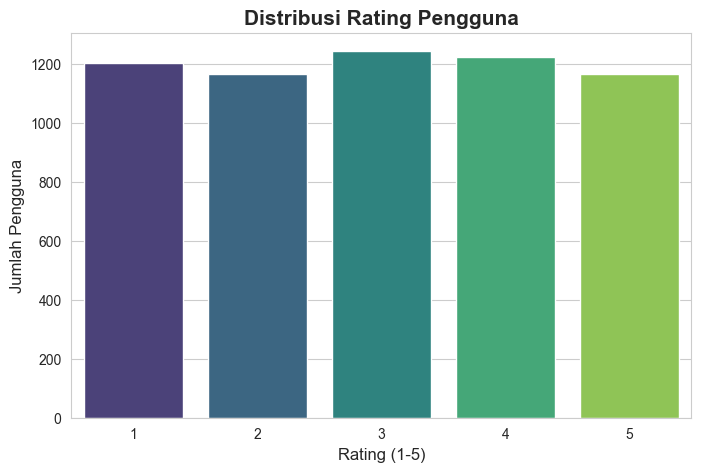

In [9]:
# Membuat visualisasi, dan ukurannya
plt.figure(figsize=(8, 5))

# membuat grafing batang dan menghitung jumlah data rating
sns.countplot(data=df, x='rating', palette='viridis')

plt.title('Distribusi Rating Pengguna', fontsize=15, fontweight='bold') # judul
plt.xlabel('Rating (1-5)', fontsize=12) # sumbu x
plt.ylabel('Jumlah Pengguna', fontsize=12) # sumbu y
plt.show()

### 🔎 Analisa Distribusi Rating

1. Distribusi rating relatif **merata pada nilai 1 hingga 5**.
2. Rating **3** memiliki jumlah pengguna terbanyak.
3. Rating **5** memiliki jumlah paling sedikit.
4. Pola ini menunjukkan preferensi pengguna cukup beragam dan tidak didominasi oleh rating ekstrem.


### 🔹 EDA 3 - Restoran Paling Populer

In [10]:
# Total pesanan per restoran
top_restaurants = (
    # kelompokkan data berdasar nama restoran
    df.groupby('restaurant_name')
      .size() # menghitung jumlah baris
      .reset_index(name='total_orders') # ubah hasil groupby menjadi DataFrame
      .sort_values(by='total_orders', ascending=False) # sorting
)

display(top_restaurants.head(10).style.hide(axis="index"))


restaurant_name,total_orders
Subway,1260
Pizza Hut,1224
KFC,1224
Burger King,1151
McDonald's,1141


### --- Visualisasi Top 10 Restoran ---

C:\Users\Hammam Karim\AppData\Local\Temp\ipykernel_30324\2847437672.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_restaurants.head(10), y='restaurant_name', x='total_orders', palette='magma')


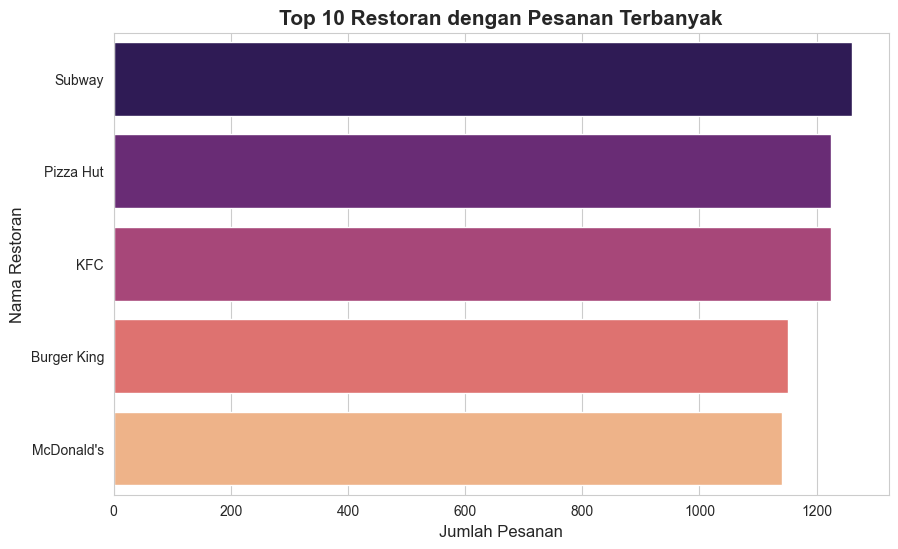

In [11]:
plt.figure(figsize=(10, 6))

# Mengambil 10 data teratas dari variabel top_restaurants
# membuat barplot dengan variabel y adalah restaurant_name dan x adalah total_orders
sns.barplot(data=top_restaurants.head(10), y='restaurant_name', x='total_orders', palette='magma')

plt.title('Top 10 Restoran dengan Pesanan Terbanyak', fontsize=15, fontweight='bold')
plt.xlabel('Jumlah Pesanan', fontsize=12)
plt.ylabel('Nama Restoran', fontsize=12)
plt.show()

### 🔎 Analisa Popularitas Restoran

1. Subway merupakan restoran dengan **jumlah pesanan tertinggi**.
2. Pizza Hut dan KFC memiliki tingkat popularitas yang  sama.
3. Perbedaan jumlah pesanan antar restoran relatif tidak terlalu jauh.
4. Data ini dapat dimanfaatkan sebagai dasar **popularity-based recommendation** dalam sistem.


### 🔹 EDA 4 – Menu Paling Sering Dipesan

In [12]:
# Total pesanan per menu
top_dishes = (
  # kelompokkan data berdasar nama makanan
    df.groupby('dish_name')
      .size() # menghitung jumlah baris
      .reset_index(name='total_orders') # ubah hasil groupby menjadi DataFrame
      .sort_values(by='total_orders', ascending=False)  # sorting
)

display(top_dishes.head(10).style.hide(axis="index"))

dish_name,total_orders
Pasta,1262
Sandwich,1243
Pizza,1200
Fries,1152
Burger,1143


### --- Visualisasi Menu Makanan ---

C:\Users\Hammam Karim\AppData\Local\Temp\ipykernel_30324\350251031.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_dishes.head(10), x='dish_name', y='total_orders', palette='coolwarm')


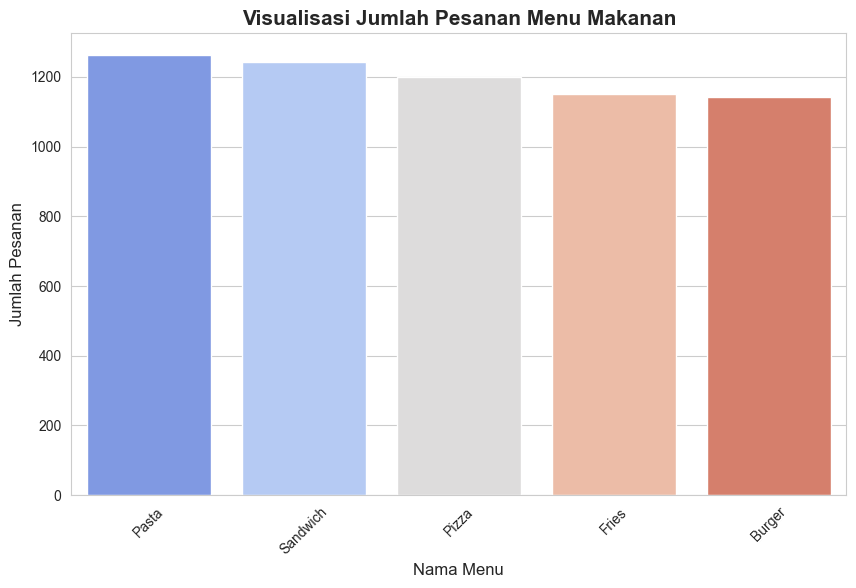

In [13]:
plt.figure(figsize=(10, 6))

# membuat barplot dengan variabel x adalah dish_name dan y adalah total_orders
sns.barplot(data=top_dishes.head(10), x='dish_name', y='total_orders', palette='coolwarm')

plt.title('Visualisasi Jumlah Pesanan Menu Makanan', fontsize=15, fontweight='bold')
plt.xlabel('Nama Menu', fontsize=12)
plt.ylabel('Jumlah Pesanan', fontsize=12)
plt.xticks(rotation=45) # memutar label sumbu x agar tidak tumpang tindih
plt.show()

### 🔎 Analisa Popularitas Menu

1. Pasta merupakan menu dengan **jumlah pesanan tertinggi**.
2. Menu Burger dengan jumlah pemesanan terendah
3. Perbedaan jumlah pesanan antar menu relatif tidak terlalu signifikan.
4. Informasi ini dapat digunakan sebagai dasar **rekomendasi menu populer** dalam sistem.

### --- Visualisasi Distribusi Harga ---

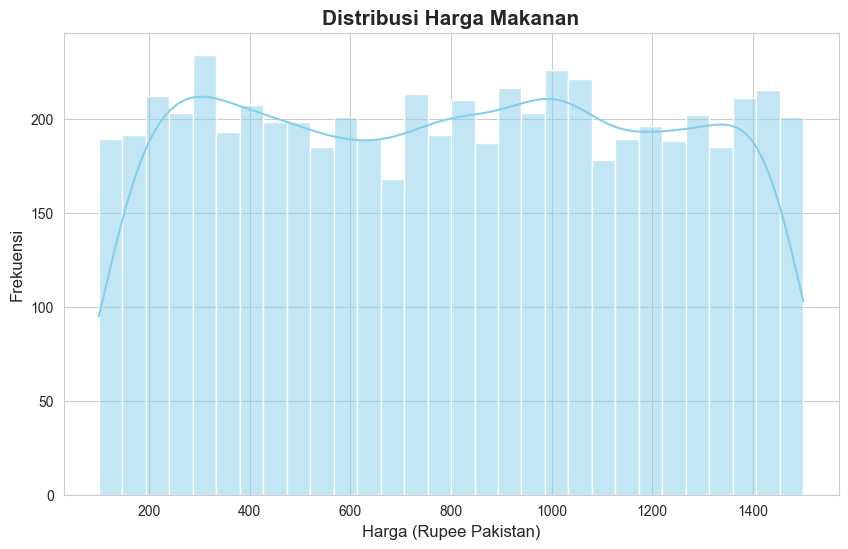

In [14]:
plt.figure(figsize=(10, 6))
# Membuat histogram untuk melihat sebaran harga
sns.histplot(df['price'], kde=True, color='skyblue', bins=30) # data interval 30

plt.title('Distribusi Harga Makanan', fontsize=15, fontweight='bold')
plt.xlabel('Harga (Rupee Pakistan)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

### 🔎 Analisa Distribusi Harga
1. **Mayoritas Harga:** Sebagian besar menu makanan memiliki harga di kisaran **rendah hingga menengah** (lihat puncak grafik).
2. **Keterjangkauan:** Distribusi harga yang condong ke kiri (skewed) menunjukkan bahwa aplikasi ini lebih banyak menawarkan opsi makanan yang terjangkau bagi pengguna.


### 🔹 EDA 5 - Aktivitas Pengguna

In [15]:
# Ringkasan aktivitas pengguna berdasarkan order_frequency
user_activity = (
  # Mengelompokkan data berdasarkan ID pelanggan
    df.groupby('customer_id')['order_frequency']
    # Memilih kolom order_frequency dan menghitung rata-rata order_frequency untuk setiap pengguna
      .mean() 
      .reset_index(name='avg_order_frequency') # ubah hasil menjadi DataFrame
      .sort_values(by='avg_order_frequency', ascending=False) # sorting
)

display(user_activity.head(10).style.hide(axis="index"))

customer_id,avg_order_frequency
C4667,50.000000
C4658,50.000000
C3572,50.000000
C5398,50.000000
C6952,50.000000
C5388,50.000000
C6566,50.000000
C4878,50.000000
C1778,50.000000
C6505,50.000000


### --- Visualisasi Aktivitas Pengguna ---

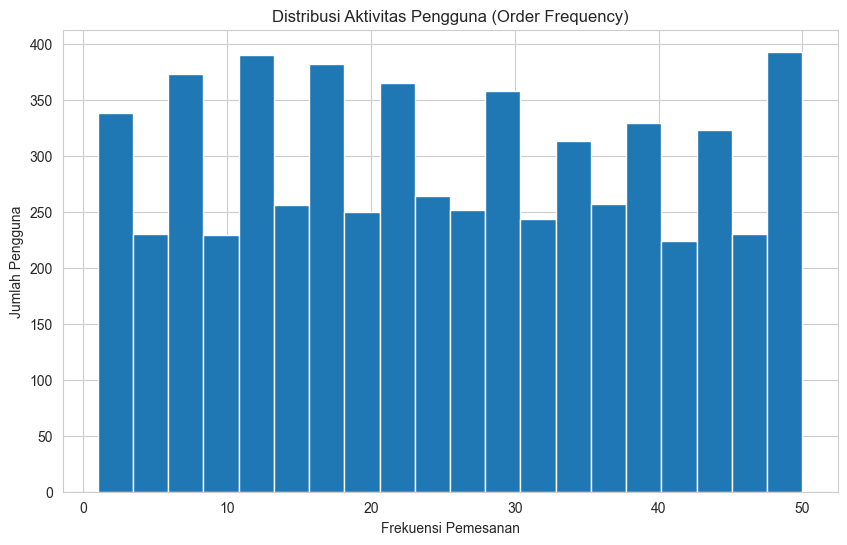

In [16]:
# Aktivitas pengguna berdasarkan frekuensi pemesanan
plt.figure()
plt.hist(df['order_frequency'], bins=20)
plt.title('Distribusi Aktivitas Pengguna (Order Frequency)')
plt.xlabel('Frekuensi Pemesanan')
plt.ylabel('Jumlah Pengguna')
plt.show()


### 🔎 Analisa Aktivitas Pengguna (Order Frequency)
1. Nilai order_frequency menunjukkan jumlah transaksi yang telah dilakukan oleh seorang pengguna, tanpa menunjukkan jenis atau variasi menu yang dipesan.
2. Setiap bar pada histogram merepresentasikan **jumlah pengguna pada rentang frekuensi pemesanan tertentu**.
3. Visualisasi menunjukkan adanya **variasi tingkat aktivitas pengguna**, dari frekuensi rendah hingga sangat tinggi.
4. Tabel yang ditampilkan merupakan **sebagian data**, sehingga beberapa pengguna memiliki nilai rata-rata frekuensi yang sama.

### 🔹 EDA 6 – Rata-rata Rating per Restoran

In [17]:
# Rata-rata rating setiap restoran
restaurant_ratings = (
  # kelompokkan data berdasar nama restoran
    df.groupby('restaurant_name')['rating']
    # hitung rata-rata rating untuk setiap restoran
      .mean()
      .reset_index(name='avg_rating') # ubah hasil menjadi DataFrame
      .sort_values(by='avg_rating', ascending=False) # sorting
)

display(restaurant_ratings.head(10).style.hide(axis="index"))

restaurant_name,avg_rating
Subway,3.087302
McDonald's,3.002629
KFC,2.974673
Burger King,2.966116
Pizza Hut,2.949346


### --- Visualisasi Rata-rata Rating Restoran ---

C:\Users\Hammam Karim\AppData\Local\Temp\ipykernel_30324\4004076435.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_rating_rest.head(10), x='rating', y='restaurant_name', palette='viridis')


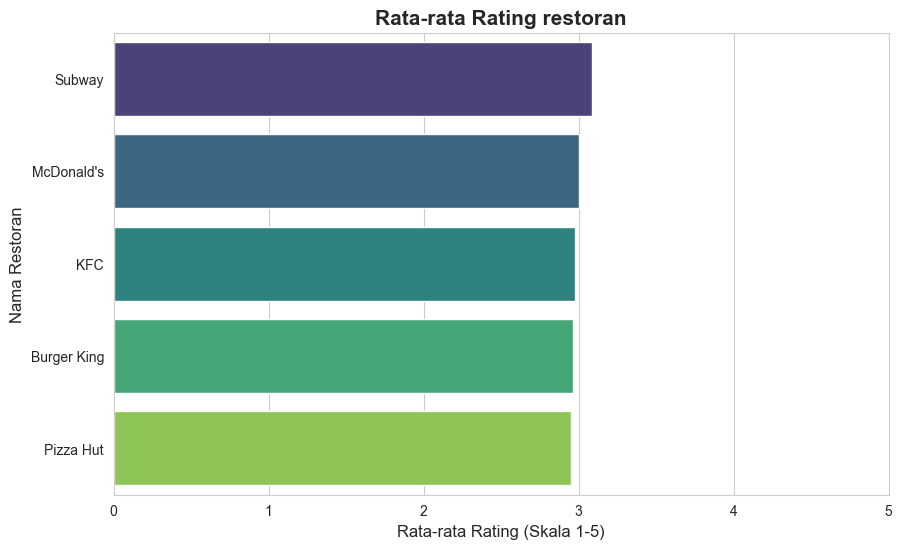

In [18]:
plt.figure(figsize=(10, 6))

# 1. Menghitung rata-rata rating per restoran (seperti tabel temanmu)
avg_rating_rest = df.groupby('restaurant_name')['rating'].mean().sort_values(ascending=False).reset_index()

# 2. Visualisasi Bar Chart
sns.barplot(data=avg_rating_rest.head(10), x='rating', y='restaurant_name', palette='viridis')

plt.title('Rata-rata Rating restoran', fontsize=15, fontweight='bold')
plt.xlabel('Rata-rata Rating (Skala 1-5)', fontsize=12)
plt.ylabel('Nama Restoran', fontsize=12)
plt.xlim(0, 5) # Memastikan sumbu X mentok di angka 5
plt.show()

### 🔎 Analisa Rata-rata Rating Restoran

1. Subway memiliki **rata-rata rating tertinggi** dibandingkan restoran lainnya.
2. Secara umum, tingkat kepuasan pengguna terhadap restoran berada pada **kategori sedang**.
3. Informasi ini dapat dimanfaatkan untuk mendukung **rekomendasi restoran berbasis kualitas**.
---


### --- Visualisasi Korelasi Antar Variabel (Heatmap) ---

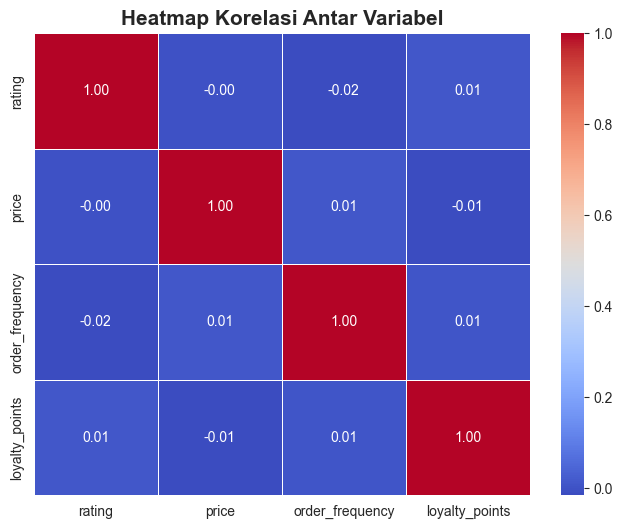

In [19]:
plt.figure(figsize=(8, 6))
# Kita hanya mengambil kolom yang berisi angka (numerik) untuk melihat hubungannya
numerical_cols = ['rating', 'price', 'order_frequency', 'loyalty_points']
# Menghitung matriks korelasi
correlation = df[numerical_cols].corr()

# Membuat Heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) 
plt.title('Heatmap Korelasi Antar Variabel', fontsize=15, fontweight='bold')
plt.show()

### 🔎Analisis Korelasi Antar Variabel

1. Tidak terdapat **korelasi kuat** antar variabel (semua nilai mendekati 0).
2. **Rating** tidak berkorelasi signifikan dengan **price** maupun **order_frequency**.
3. **Order_frequency** dan **loyalty_points** memiliki korelasi sangat lemah.
5. Menunjukkan bahwa setiap variabel **relatif independen** dan memberi kontribusi berbeda dalam analisis/rekomendasi.


## 4️⃣ Pembentukan Profil User & Item

Merepresentasikan karakteristik User & item sebagai dasar dalam sistem rekomendasi berbasis konten dan popularitas.


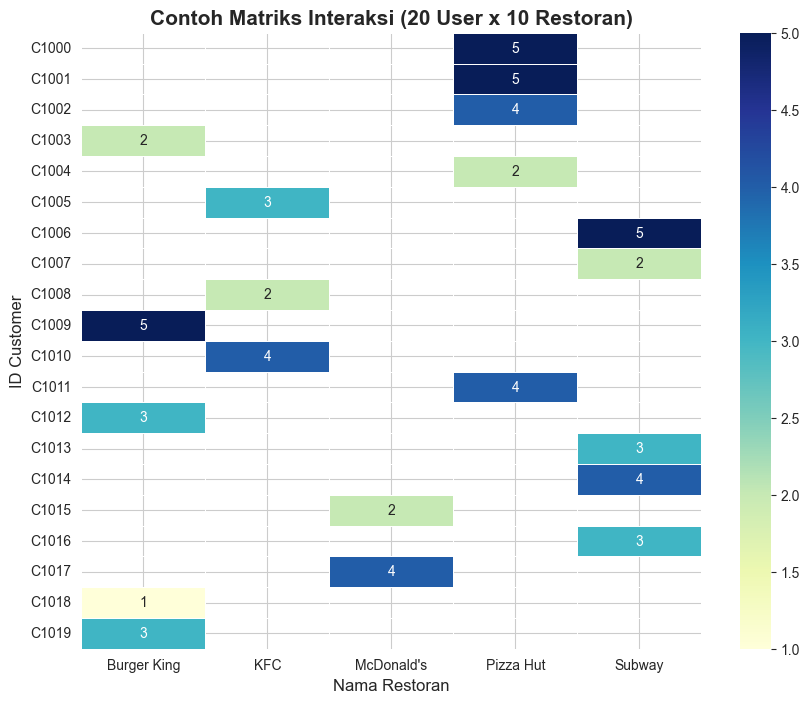

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# mengubah data mentah menjadi matriks interaksi
# index adalah customer_id, kolom adalah restaurant_name, dan nilainya adalah rating
interaction_sample = df.pivot_table(index='customer_id', columns='restaurant_name', values='rating').iloc[:20, :10] # mengambil 20 pertama

# Membuat heatmap dari matriks interaksi
sns.heatmap(interaction_sample, cmap='YlGnBu', annot=True, fmt=".0f", linewidths=.5)

plt.title('Contoh Matriks Interaksi (20 User x 10 Restoran)', fontsize=15, fontweight='bold')
plt.xlabel('Nama Restoran', fontsize=12)
plt.ylabel('ID Customer', fontsize=12)
plt.show()

### 🔎 Analisis Matriks Interaksi User–Restoran

1. Matriks interaksi menunjukkan **interaksi rating yang sparsity tinggi** (banyak nilai kosong).
2. Setiap user hanya memberi rating pada **sebagian kecil restoran**.
3. Nilai rating bervariasi (1–5), menandakan **preferensi user berbeda-beda**.


In [21]:
# Representasi profil pengguna

# Profil user berdasarkan preferensi konten
# mengelompokkan data berdasarkan customer_id
user_profile = df.groupby('customer_id').agg({ # melakukan agregasi multi kolom
    'category': 'first', # mengambil nilai pertama dari kategori user tsb
    'restaurant_name': 'first', # mengambil nama restoran pertama
    'price': 'mean', # Menghitung rata-rata harga makanan yang dipesan user
    'order_frequency': 'first'# mengambil frekuensi pemesanan pertama
}).reset_index()

user_profile.head()


,customer_id,category,restaurant_name,price,order_frequency
0,C1000,Italian,Pizza Hut,1210.10,26
1,C1001,Fast Food,Pizza Hut,322.72,45
2,C1002,Dessert,Pizza Hut,1452.54,46
3,C1003,Fast Food,Burger King,133.44,16
4,C1004,Chinese,Pizza Hut,1044.89,40


In [22]:
# Representasi Profil Item (Menu & Restoran)

# Profil item (menu)
item_profile = df[['dish_name', 'category', 'restaurant_name', 'price']].drop_duplicates()
item_profile.head()

,dish_name,category,restaurant_name,price
0,Burger,Italian,McDonald's,1478.27
1,Burger,Italian,KFC,956.04
2,Fries,Italian,Pizza Hut,882.51
3,Pizza,Dessert,Subway,231.30
4,Sandwich,Dessert,KFC,1156.69


Profil item dibentuk dari atribut konten yang melekat pada menu dan restoran.

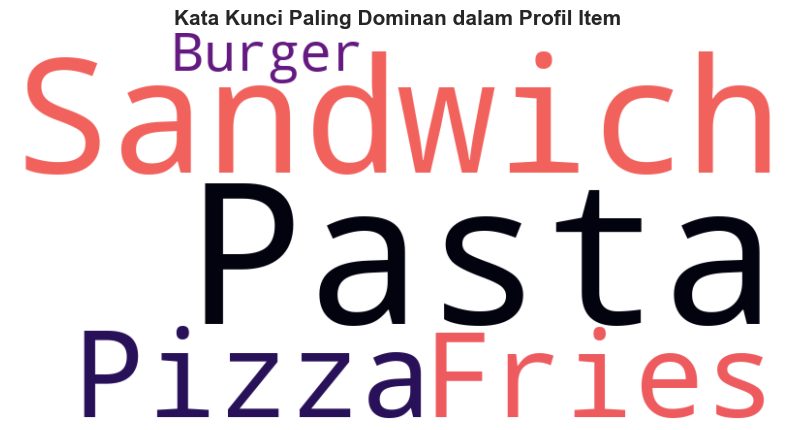

In [23]:
# --- VISUALISASI WORD CLOUD DESKRIPSI MAKANAN ---

# Menggabungkan semua nama makanan/kategori menjadi satu teks panjang
text = " ".join(review for review in df['dish_name'].astype(str))

# Membuat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(text)

plt.figure(figsize=(10, 6))
# menampilkan gambar word cloud dan interpolasi bilinear untuk hasil yang lebih halus
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Menghilangkan sumbu X dan Y
plt.title('Kata Kunci Paling Dominan dalam Profil Item', fontsize=15, fontweight='bold')
plt.show()

In [24]:
# Popularitas menu berdasarkan jumlah pesanan
item_popularity = (
  # kelompokkan data berdasar nama makanan
    df.groupby('dish_name')
      .size() # menghitung jumlah baris
      .reset_index(name='total_orders') # ubah hasil groupby menjadi DataFrame
      .sort_values(by='total_orders', ascending=False) # sorting
)

display(item_popularity.head().style.hide(axis="index"))


dish_name,total_orders
Pasta,1262
Sandwich,1243
Pizza,1200
Fries,1152
Burger,1143


## 5️⃣ Popularity-Based Recommendation

Membangun sistem rekomendasi berdasarkan tingkat popularitas item.


In [25]:
# Perhitungan popularitas item menu
# Popularitas menu berdasarkan jumlah pesanan
popularity_score = (
    df.groupby('dish_name') # mengelompokkan berdasarkan nama makanan
      .agg( # melakukan agregasi multi kolom
          total_orders=('dish_name', 'count'), # menghitung jumlah pesanan setiap menu
          # avg_rating=('rating', 'mean')  # menghitung rata-rata rating setiap menu
      )
      .reset_index() # mengubah hasil groupby menjadi DataFrame
      .sort_values(by='total_orders', ascending=False) # sorting
)

display(popularity_score.head().style.hide(axis="index"))


dish_name,total_orders
Pasta,1262
Sandwich,1243
Pizza,1200
Fries,1152
Burger,1143


In [26]:
popularity_df = (
    # menghitung popularitas menu berdasarkan jumlah pesanan
    df.groupby('dish_name')
      .agg(     # melakukan agregasi multi kolom
          total_orders=('dish_name', 'count'), # menghitung jumlah pesanan setiap menu
          # avg_rating=('rating', 'mean') # menghitung rata-rata rating setiap menu
      )
      .reset_index()
)

# Membuat skor popularitas (0–1) untuk setiap item/menu
popularity_df['popularity_score'] = (
    # jumlah pesanan tiap menu dibagi dengan jumlah pesanan tertinggi di antara semua menu
    # PR Metode
    popularity_df['total_orders'] / popularity_df['total_orders'].max() 
)
display(popularity_df.head().style.hide(axis="index"))

dish_name,total_orders,popularity_score
Burger,1143,0.905705
Fries,1152,0.912837
Pasta,1262,1.000000
Pizza,1200,0.950872
Sandwich,1243,0.984945


C:\Users\Hammam Karim\AppData\Local\Temp\ipykernel_30324\3576638049.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_popular, x='popularity_score', y='dish_name', palette='rocket')


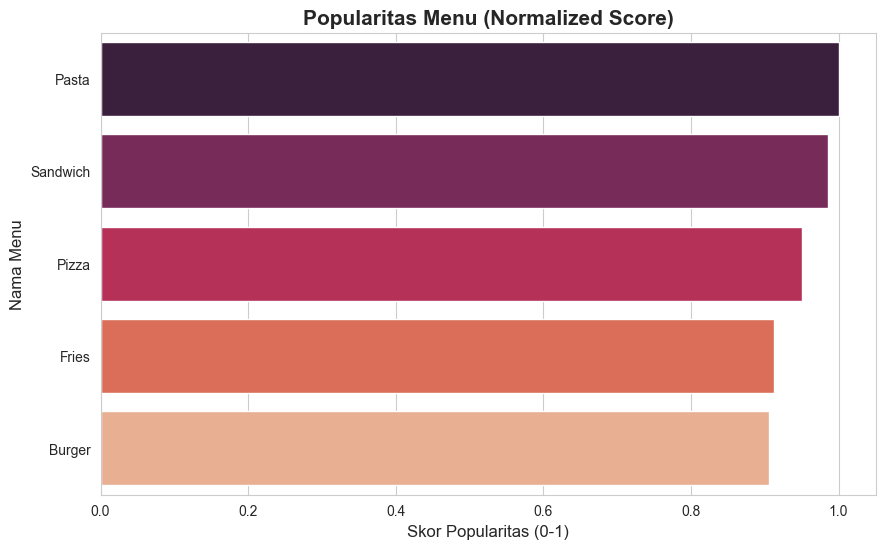

In [27]:
# --- VISUALISASI BAGIAN HYBRID: POPULARITAS MENU ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Reset_index karena nama makanan ada di index
top_popular = popularity_df.sort_values('popularity_score', ascending=False).head(10).reset_index()

# membuat barplot dengan variabel x adalah popularity_score dan y adalah dish_name
sns.barplot(data=top_popular, x='popularity_score', y='dish_name', palette='rocket')

plt.title('Popularitas Menu (Normalized Score)', fontsize=15, fontweight='bold')
plt.xlabel('Skor Popularitas (0-1)', fontsize=12)
plt.ylabel('Nama Menu', fontsize=12)
plt.show()

1. Menu dengan **total_orders tertinggi** merupakan menu paling populer berdasarkan frekuensi pemesanan.
2. **Avg_rating** menggambarkan kualitas, sehingga menu populer belum tentu memiliki rating tertinggi.
3. Popularity_score adalah skor popularitas yang dinormalisasi (0–1), sehingga memungkinkan perbandingan adil antar menu meskipun skala nilai total_orders berbeda.
4. Dengan Popularity_score, Pasta menjadi menu paling populer secara keseluruhan, dan burger adalah yang paling rendah.
5. Hasil ini digunakan sebagai dasar **popularity-based recommendation** atau sebagai komponen pada **hybrid recommendation system**.

In [28]:
restaurant_popularity = (
    df.groupby('restaurant_name') # mengelompokkan berdasarkan nama restoran
      .agg( # melakukan agregasi multi kolom
          total_orders=('restaurant_name', 'count'), # menghitung jumlah pesanan setiap restoran
          # avg_rating=('rating', 'mean') # menghitung rata-rata rating setiap restoran
      )
      .reset_index() # mengubah hasil groupby menjadi DataFrame
      .sort_values(by='total_orders', ascending=False) # sorting
)
display(restaurant_popularity.head().style.hide(axis="index"))

restaurant_name,total_orders
Subway,1260
Pizza Hut,1224
KFC,1224
Burger King,1151
McDonald's,1141


1. **Subway** menjadi restoran paling populer berdasarkan jumlah pesanan tertinggi
2. **Pizza Hut** dan **KFC** memiliki jumlah pesanan yang sama tinggi, namun **rating KFC sedikit lebih baik**.
3. **McDonald's** memiliki jumlah pesanan paling rendah.
---


## 6️⃣ Content-Based Filtering
Menghasilkan rekomendasi berdasarkan kemiripan karakteristik konten


In [29]:
# Fitur Konten yang Digunakan
# Menggabungkan fitur konten menjadi satu kolom
df['content_features'] = ( #kolom baru bernama content_features, berisi gabungan informasi konten dari setiap menu
    # df['dish_name'] + ' ' + # menggabungkan nama makanan
    df['restaurant_name'] + ' ' + # menggabungkan kategori makanan
    df['category'] # menggabungkan nama restoran
)
 # menampilkan 5 baris pertama dari kolom dish_name dan content_features
df[['dish_name', 'content_features']].head()


,dish_name,content_features
0,Burger,McDonald's Italian
1,Burger,KFC Italian
2,Fries,Pizza Hut Italian
3,Pizza,Subway Dessert
4,Sandwich,KFC Dessert


In [30]:
# Perhitungan Kemiripan Konten Item menggunakan One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder # import OneHotEncoder dari sklearn
from sklearn.metrics.pairwise import cosine_similarity # import cosine_similarity

# Ambil fitur konten untuk OHE
content_ohe_data = df[['restaurant_name', 'category']]

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False) # inisialisasi OneHotEncoder
content_ohe_matrix = ohe.fit_transform(content_ohe_data) # melakukan fit dan transformasi data konten menjadi matriks OHE

# Hitung cosine similarity antar item (menu)
content_similarity = cosine_similarity(content_ohe_matrix)

# Contoh: tampilkan 5x5 pertama Matriks Content Similarity
content_similarity[:5, :5]


array([[1. , 0.5, 0.5, 0. , 0. ],
       [0.5, 1. , 0.5, 0. , 0.5],
       [0.5, 0.5, 1. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0.5],
       [0. , 0.5, 0. , 0.5, 1. ]])

1. Nilai **1.0 pada diagonal** menunjukkan setiap menu memiliki kemiripan sempurna.
2. Nilai **0.5** menandakan dua menu memiliki **satu kesamaan fitur** (restoran atau kategori), sedangkan **0.0** berarti **tidak ada kesamaan konten sama sekali**.


In [31]:
# Menampilkan Skor Kemiripan Konten per Menu

# Pilih item acuan
item_index = 0

# Ambil informasi acuan (CONTENT)
acuan_dish = df.iloc[item_index]['dish_name'] # ambil nama menu
acuan_restaurant = df.iloc[item_index]['restaurant_name'] # ambil nama restoran
acuan_category = df.iloc[item_index]['category'] # ambil kategori

# Ambil skor similarity terhadap semua item
similarity_scores = list(enumerate(content_similarity[item_index]))

# Buat DataFrame similarity
similarity_df = pd.DataFrame( 
    similarity_scores, # membuat DataFrame dari daftar skor similarity
    columns=['index', 'content_similarity_score'] # penamaan kolom
)

# Gabungkan dengan informasi menu
similarity_df = similarity_df.merge(
    df[['dish_name', 'restaurant_name', 'category']], # menggabungkan dengan DataFrame asli untuk mendapatkan informasi menu
    left_on='index', # menggabungkan berdasarkan index
    right_index=True # menggabungkan berdasarkan index kanan
)

#  tampilkan 10 data pertama
from IPython.display import display

# menampilkan tabel dengan format rapi, menyembunyikan index, dan memformat skor similarity hingga 3 desimal
display(
    similarity_df.head(10) # mengambil 10 baris pertama
    .style # menggunakan styler untuk format tabel
    .hide(axis="index") # menyembunyikan index
    .format({'content_similarity_score': '{:.3f}'}) # format skor similarity hingga 3 desimal
)

# Tampilkan informasi acuan (CONTENT yang dipertimbangkan)
print("Acuan Content-Based Recommendation:")
print(f"Menu       : {acuan_dish}") # menampilkan nama menu
print(f"Restoran   : {acuan_restaurant}") # menampilkan nama restoran
print(f"Kategori   : {acuan_category}") # menampilkan kategori




index,content_similarity_score,dish_name,restaurant_name,category
0,1.000,Burger,McDonald's,Italian
1,0.500,Burger,KFC,Italian
2,0.500,Fries,Pizza Hut,Italian
3,0.000,Pizza,Subway,Dessert
4,0.000,Sandwich,KFC,Dessert
5,0.000,Pizza,Burger King,Fast Food
6,0.500,Pasta,McDonald's,Continental
7,0.000,Pizza,Pizza Hut,Chinese
8,0.000,Pizza,KFC,Dessert
9,0.000,Pizza,Pizza Hut,Continental


Acuan Content-Based Recommendation:
Menu       : Burger
Restoran   : McDonald's
Kategori   : Italian


1. Menu acuan **Burger – McDonald’s (Italian)** memiliki skor kemiripan **1.000**, menandakan kecocokan konten penuh.
2.  Menu lain dengan kategori atau restoran yang sama memperoleh skor **0.5**, sedangkan menu dengan kategori berbeda bernilai **0.0**, menunjukkan bahwa similarity murni ditentukan oleh kesamaan kategori/restoran hasil One-Hot Encoding.


## 7️⃣ Hybrid Recommendation System

Menggabungkan rekomendasi berbasis popularitas dan kemiripan konten untuk menghasilkan rekomendasi yang lebih relevan dan stabil.


In [32]:
# Normalisasi skor popularitas
popularity_df['popularity_score'] = ( # membuat skor popularitas (0-1) untuk setiap item/menu
    # jumlah pesanan tiap menu dibagi dengan jumlah pesanan tertinggi di antara semua menu
    popularity_df['total_orders'] / popularity_df['total_orders'].max()
)

# Contoh pengambilan similarity item (berdasarkan index)
item_index = 0 # item acuan
content_scores = list(enumerate(content_similarity[item_index])) # mendapatkan skor kemiripan antara item acuan dengan semua item lain.

# Membuat DataFrame untuk skor konten
content_df = pd.DataFrame(content_scores, columns=['index', 'content_score'])

# Gabungkan skor popularity dan content
hybrid_df = df.reset_index().merge( # menggabungkan data frame df dengan popularity_df berdasarkan nama makanan
    popularity_df[['dish_name', 'popularity_score']], # mengambil hanya kolom dish_name dan popularity_score dari popularity_df
    on='dish_name', # menggabungkan berdasarkan nama makanan
    how='left' # menggabungkan dengan metode left join
).merge( # menggabungkan dengan data frame content_df berdasarkan index
    content_df, 
    left_on='index', # menggabungkan berdasarkan index
    right_on='index' # menggabungkan berdasarkan index
)

# Hitung skor hybrid
hybrid_df['hybrid_score'] = (
    0.6 * hybrid_df['popularity_score'] + # bobot 60% untuk popularitas
    0.4 * hybrid_df['content_score'] # bobot 40% untuk kemiripan konten
)

# Menghasilkan rekomendasi akhir berdasarkan skor hybrid
final_recommendation = (
    hybrid_df 
    .groupby(['dish_name', 'restaurant_name'], as_index=False) # mengelompokkan berdasarkan nama makanan dan restoran
    .agg(hybrid_score=('hybrid_score', 'mean')) # menghitung rata-rata skor hybrid untuk setiap kombinasi makanan dan restoran
    .sort_values(by='hybrid_score', ascending=False) # mengurutkan berdasarkan skor hybrid secara menurun
    .head(10)
)

# from IPython.display import display
# display(final_recommendation.style.hide(axis="index"))

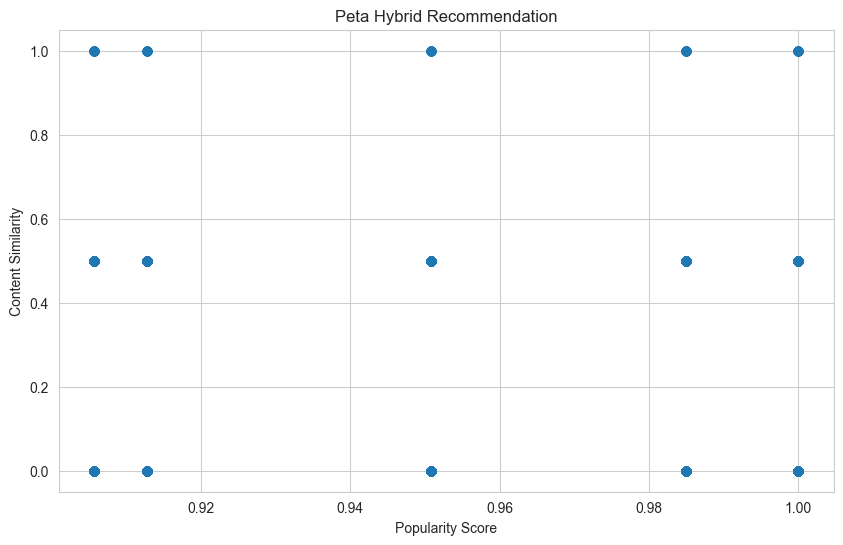

In [33]:
plt.figure()
plt.scatter(hybrid_df['popularity_score'], hybrid_df['content_score'])
plt.xlabel("Popularity Score")
plt.ylabel("Content Similarity")
plt.title("Peta Hybrid Recommendation")
plt.show()


1. Titik menyebar di sepanjang sumbu Popularity Score (0.90 – 1.00), menunjukkan hampir semua item punya tingkat popularitas cukup tinggi.
2. Content Similarity bervariasi (0.0 – 1.0), artinya kedekatan konten antara item sangat beragam, dari tidak mirip sama sekali hingga sangat mirip.
3. Tidak terlihat korelasi kuat antara Popularity Score dan Content Similarity (titik tersebar acak), artinya item yang populer tidak selalu mirip kontennya.
4. Titik dengan Popularity Score tinggi (0.98–1.00) tetap memiliki variasi similarity rendah – tinggi, cocok untuk rekomendasi hybrid agar hasil lebih beragam.
---

## 8️⃣ Hasil Rekomendasi

Pada tahap ini, sistem menampilkan hasil rekomendasi akhir berdasarkan skor hybrid 
yang telah dibentuk pada tahap sebelumnya. Rekomendasi disajikan dalam bentuk 
Top-N menu dan restoran dengan skor tertinggi.


In [34]:
# Menghasilkan rekomendasi akhir berdasarkan skor hybrid
final_recommendation = (
    hybrid_df # mengelompokkan berdasarkan nama makanan dan restoran
    .groupby(['dish_name', 'restaurant_name'], as_index=False) 
    .agg(hybrid_score=('hybrid_score', 'mean')) # menghitung rata-rata skor hybrid untuk setiap kombinasi makanan dan restoran
)

In [35]:
top_n = 10

# Mengambil top N rekomendasi berdasarkan skor hybrid
top_recommendation = (
    final_recommendation
    .sort_values(by='hybrid_score', ascending=False) # mengurutkan berdasarkan skor hybrid secara menurun
    .head(top_n)
)

In [36]:
from IPython.display import display
# menampilkan top rekomendasi berdasarkan skor hybrid
display(top_recommendation.style.hide(axis="index")) 


dish_name,restaurant_name,hybrid_score
Pasta,McDonald's,0.847222
Sandwich,McDonald's,0.833590
Pizza,McDonald's,0.810171
Burger,McDonald's,0.785700
Fries,McDonald's,0.784241
Pasta,Subway,0.642215
Pasta,Burger King,0.641975
Sandwich,Subway,0.640105
Sandwich,KFC,0.637299
Pasta,KFC,0.637037


### 🔎 Analisa Hasil Rekomendasi Hybrid

1. Rekomendasi didominasi oleh menu dari **McDonald's**, menunjukkan kombinasi popularitas dan kemiripan konten yang tinggi.
2. Menu **Burger** memiliki skor hybrid tertinggi, menandakan daya tarik dan permintaan yang konsisten.
3. Restoran lain seperti **Burger King** dan **Subway** tetap muncul, menunjukkan sistem tidak bias pada satu restoran saja.
4. Perbedaan skor antar menu relatif kecil, menandakan kualitas rekomendasi yang kompetitif.
5. Hasil ini merepresentasikan rekomendasi **non-personalisasi** berbasis karakteristik item.

## 9️⃣ Evaluasi Sistem

1. NDCG (Normalized Discounted Cumulative Gain) @10: Menilai *urutan ranking* apakah item relevan ditempatkan di posisi atas
2. MAP (Mean Average Precision) @10: Menilai seberapa tepat rekomendasi (apakah item yang direkomendasikan benar-benar relevan)
3. Coverage: Seberapa luas sistem menampilkan variasi menu, bukan hanya menu itu-itu saja
4. Popularity Bias: Menilai apakah sistem terlalu condong ke makanan yang populer saja
5. Hit Rate@10: Setidaknya satu item relevan berhasil muncul dalam daftar Top-10 rekomendasi

In [37]:
import numpy as np

# Ambil item relevan (ground truth)
relevant_items = set(
    df[df['rating'] >= 4]['dish_name'] # mengambil nama makanan dengan rating 4 atau lebih 
    .unique() # mengambil nilai unik saja
)

# Ambil item hasil rekomendasi hybrid
recommended_items = list( 
    final_recommendation['dish_name'] # mengambil nama makanan dari final_recommendation
)

# Pastikan final_recommendation masih punya rating & popularity
final_eval = final_recommendation.merge(
    hybrid_df[['dish_name', 'rating', 'popularity_score']].drop_duplicates(),
    on='dish_name',
    how='left'
)

K = 10  # Top-K rekomendasi

scores = list(final_eval["hybrid_score"])

# NDCG@K — Kualitas Ranking
def ndcg_at_k(scores, k):
    dcg = sum((score / np.log2(idx + 2)) for idx, score in enumerate(scores[:k]))
    ideal = sorted(scores, reverse=True)
    idcg = sum((score / np.log2(idx + 2)) for idx, score in enumerate(ideal[:k]))
    return dcg / idcg if idcg != 0 else 0

ndcg = ndcg_at_k(scores, K)

# 🚀 2️⃣ MAP@K — Ketepatan rekomendasi berdasarkan item relevan
# relevansi = rating >= 4
def apk(df, k):
    relevant_items = set(df[df['rating'] >= 4]['dish_name'].unique())
    recommended = list(df['dish_name'][:k])
    score = 0.0
    hits = 0
    for i, item in enumerate(recommended):
        if item in relevant_items:
            hits += 1
            score += hits / (i + 1)
    return score / max(1, min(len(relevant_items), k))

mapk = apk(final_eval, K)

# overage — Seberapa banyak item baru yg muncul
coverage = (
    len(final_eval['dish_name'].unique())
    / len(hybrid_df['dish_name'].unique())
)

#  Popularity Bias — Bias ke menu populer
avg_pop_rec = final_eval['popularity_score'][:K].mean()
avg_pop_all = hybrid_df['popularity_score'].mean()
pop_bias = avg_pop_rec / avg_pop_all

# Hitung Hit Rate@K
hit_rate_at_k = int( 
    len(set(recommended_items[:K]) & relevant_items) > 0 
)

# Print hasil evaluasi
print("=== 📊 Evaluasi Sistem — Hybrid Recommendations ===")
print(f"NDCG@{K}: {ndcg:.4f}")
print(f"MAP@{K}: {mapk:.4f}")
print(f"Hit Rate@{K}: {hit_rate_at_k}")
print(f"Coverage: {coverage:.4f}")
print(f"Popularity Bias: {pop_bias:.4f}")


=== 📊 Evaluasi Sistem — Hybrid Recommendations ===
NDCG@10: 0.6962
MAP@10: 2.0000
Hit Rate@10: 1
Coverage: 1.0000
Popularity Bias: 0.9510


C:\Users\Hammam Karim\AppData\Local\Temp\ipykernel_30324\195116430.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Metric', y='Score', data=df_metrics, palette='viridis')


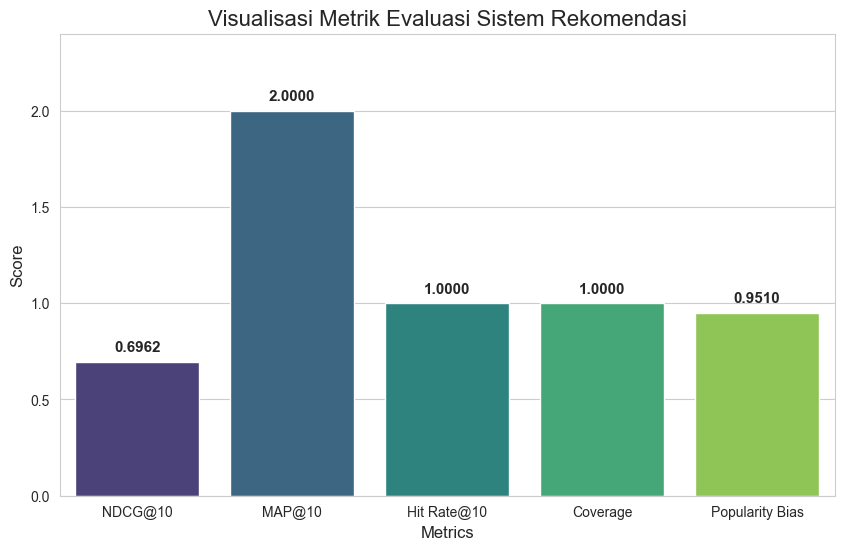

In [ ]:
# Membuat DataFrame dari hasil evaluasi
metrics_data = {
    'Metric': ['NDCG@10', 'MAP@10', 'Hit Rate@10', 'Coverage', 'Popularity Bias'],
    'Score': [ndcg, mapk, hit_rate_at_k, coverage, pop_bias]
}

df_metrics = pd.DataFrame(metrics_data)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Metric', y='Score', data=df_metrics, palette='viridis')

# Menambahkan label nilai di atas batang
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Visualisasi Metrik Evaluasi Sistem Rekomendasi', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.ylim(0, max(df_metrics['Score']) * 1.2) # Memberikan ruang di atas bar tertinggi
plt.show()

### 🔎 Hasil Evaluasi Sistem Rekomendasi

1. **NDCG@10 = 0.6962** → Urutan rekomendasi sudah cukup baik, meskipun masih ada ruang perbaikan pada kualitas ranking item teratas.  
2. **MAP@10 = 2.0000** → Sistem berhasil menempatkan item relevan (rating tinggi) di posisi awal rekomendasi secara konsisten.  
3. **Hit Rate@10 = 1** menandakan bahwa setidaknya satu item relevan berhasil muncul dalam daftar Top-10 rekomendasi.
4. **Coverage = 1.0000** → Seluruh menu dalam sistem berhasil terjangkau oleh rekomendasi, menandakan distribusi item sangat merata.  
5. **Popularity Bias = 0.9510** → Rekomendasi tidak terlalu bias ke menu populer, sehingga masih memberi peluang pada menu yang kurang populer.



## 🔟 Sistem Sederhana Pencarian Menu & Restoran - Hybrid Recommender (Interactive UI)

In [39]:
# 🔍 Sistem Pencarian Menu / Restoran (UI Interaktif) 
import ipywidgets as widgets # library untuk membuat UI interaktif
from IPython.display import display, HTML # library untuk menampilkan elemen HTML

# 1️⃣ Daftar Referensi Petunjuk
menu_list = ["Pasta", "Sandwich", "Pizza", "Fries", "Burger"] # daftar menu
resto_list = ["Subway", "Pizza Hut", "KFC", "Burger King", "McDonald's"] # daftar restoran

# 2️⃣ Fungsi Pencarian
# mencari berdasarkan nama menu
def search_by_menu(menu_name):
    # filter data berdasarkan nama menu (case insensitive)
    df_filtered = hybrid_df[hybrid_df['dish_name'].str.lower() == menu_name.lower()] 
    # jika tidak ada data yang ditemukan
    if df_filtered.empty: 
        # mengembalikan pesan error
        return f"❌ Menu '{menu_name}' tidak ditemukan." 
    # menghitung popularitas, dan skor hybrid untuk menu yang dicari
    result = ( 
        # mengelompokkan berdasarkan nama makanan dan restoran
        df_filtered.groupby(["dish_name", "restaurant_name"], as_index=False) 
        .agg( # melakukan agregasi multi kolom
            # avg_rating=("rating", "mean"), # menghitung rata-rata rating
            # popularity=("popularity_score", "mean"), # menghitung rata-rata popularitas
            hybrid_score=("hybrid_score", "mean") # menghitung rata-rata skor hybrid
        )
        # mengurutkan berdasarkan skor hybrid secara menurun
        .sort_values(by="hybrid_score", ascending=False)
        # mengatur ulang index
        .reset_index(drop=True)
    )
    return result # mengembalikan hasil pencarian

# mencari berdasarkan nama restoran
def search_by_restaurant(resto_name):
    # filter data berdasarkan nama restoran (case insensitive)
    df_filtered = hybrid_df[hybrid_df['restaurant_name'].str.lower() == resto_name.lower()]
    # jika tidak ada data yang ditemukan
    if df_filtered.empty:
        # mengembalikan pesan error
        return f"❌ Restoran '{resto_name}' tidak ditemukan."
    # menghitung rata-rata rating, popularitas, dan skor hybrid untuk restoran yang dicari
    result = (
        df_filtered.groupby(["restaurant_name", "dish_name"], as_index=False) # mengelompokkan berdasarkan nama restoran dan makanan
        .agg( # melakukan agregasi multi kolom
            # avg_rating=("rating", "mean"), # menghitung rata-rata rating
            # popularity=("popularity_score", "mean"), # menghitung rata-rata popularitas
            hybrid_score=("hybrid_score", "mean") # menghitung rata-rata skor hybrid
        )
        # mengurutkan berdasarkan skor hybrid secara menurun
        .sort_values(by="hybrid_score", ascending=False)
        # mengatur ulang index
        .reset_index(drop=True)
    )
    # mengembalikan hasil pencarian
    return result

# 3️⃣ UI Components
# membuat kotak input teks
input_box = widgets.Text( 
    placeholder='Contoh: Burger / McDonald\'s', # placeholder untuk memberikan contoh input
    description='🔎 Cari:',
    layout=widgets.Layout(width='350px') # mengatur lebar kotak input
)

# membuat dropdown untuk memilih mode pencarian
search_type = widgets.Dropdown(
    options=[('Nama Menu', 'menu'), ('Nama Restoran', 'resto')], # pilihan mode pencarian
    value='menu', # nilai default
    description='Mode:',
)

# membuat tombol cari
button = widgets.Button(
    description='Cari Sekarang', # label tombol
    icon='search', # ikon tombol
    button_style='success', # gaya tombol
    layout=widgets.Layout(width='150px') # mengatur lebar tombol
)

# membuat area output untuk menampilkan hasil pencarian
output = widgets.Output()

# 4️⃣ Event — Tombol Cari
# fungsi yang dijalankan saat tombol diklik
def on_button_click(b): 
    # membersihkan output sebelumnya
    output.clear_output()
    # mendapatkan teks input dari kotak input
    text = input_box.value.strip()
    # menentukan jenis pencarian berdasarkan pilihan dropdown
    if search_type.value == 'menu':
        result = search_by_menu(text) # mencari berdasarkan nama menu
    else:
        result = search_by_restaurant(text) # mencari berdasarkan nama restoran

    # menampilkan hasil pencarian di area output
    with output:
        if isinstance(result, str): # jika hasilnya adalah string (pesan error)
            print(result) # tampilkan pesan error
        # jika hasilnya adalah DataFrame
        else:
            display( # menampilkan DataFrame dengan format rapi
                result.style.hide(axis="index")   #  INDEX DIHILANGKAN
                .background_gradient(cmap="YlGnBu") # menambahkan gradasi warna
                .format({"avg_rating": "{:.2f}", "popularity": "{:.3f}", "hybrid_score": "{:.3f}"}) # format angka
            )

# menghubungkan fungsi on_button_click ke event klik tombol
button.on_click(on_button_click)

# 5️⃣ Render UI HTML
display(HTML(""" 
<div style='font-family:Arial; padding:12px; background:#f6f8fa;'>
    <h2 style='color:#007bff;margin-bottom:5px;'>🍔 Sistem Pencarian Menu & Restoran — Hybrid Recommender</h2>
    <p style='font-size:14px;margin-top:0; color:#333;'>Ketik nama makanan atau restoran lalu klik tombol Cari</p>

    <h4 style='color:#333;'>📜 Daftar Menu Tersedia:</h4>
    <ul style='margin-top:-5px; color:#333;'>
        <li>Pasta</li><li>Sandwich</li><li>Pizza</li><li>Fries</li><li>Burger</li>
    </ul>

    <h4 style='color:#333;'>🏪 Daftar Restoran Tersedia:</h4> 
    <ul style='margin-top:-5px; color:#333;'>
        <li>Subway</li><li>Pizza Hut</li><li>KFC</li><li>Burger King</li><li>McDonald's</li>
    </ul>
</div>
"""))

# Menampilkan komponen UI
display(search_type, input_box, button, output) 


Dropdown(description='Mode:', options=(('Nama Menu', 'menu'), ('Nama Restoran', 'resto')), value='menu')

Text(value='', description='🔎 Cari:', layout=Layout(width='350px'), placeholder="Contoh: Burger / McDonald's")

Button(button_style='success', description='Cari Sekarang', icon='search', layout=Layout(width='150px'), style…

Output()